## <a name='sec1'></a>📦 1. Instalação de Bibliotecas

In [26]:
!pip install pandas_ta -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


## <a name='sec2'></a>📁 2. Upload e Carregamento do Banco de Dados

In [12]:
import sqlite3, pandas as pd, numpy as np
from google.colab import drive

# Monta o Google Drive
#drive.mount('/content/drive')

# --- ATENÇÃO: Substitua este caminho pelo caminho real do seu arquivo .db no Google Drive ---
#db_path = '/content/drive/MyDrive/Colab Notebooks/Pós Graduação IA Aplicada/2 - Big Data e Mineração de Dados/bolsa_94_21.db' # Exemplo: /content/drive/MyDrive/MinhaPasta/meu_arquivo.db
db_path = '/content/bolsa_94_21.db'
try:
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    print(f"Conectado ao banco de dados no Google Drive: {db_path}")
except Exception as e:
    print(f"Erro ao conectar ao banco de dados: {e}")
    print("Por favor, verifique o caminho do arquivo no seu Google Drive e se ele está montado corretamente.")



Conectado ao banco de dados no Google Drive: /content/bolsa_94_21.db


In [15]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tabelas = [t[0] for t in cursor.fetchall()]
tabelas

['papel', 'eventocotacao', 'evento', 'empresa', 'cotacao']

In [16]:

dfs = {}
for tabela in tabelas:
    dfs[tabela] = pd.read_sql_query(f"SELECT * FROM {tabela}", conn)

df_cotacao = dfs.get("cotacao")
df_papel = dfs.get("papel")
df_empresa = dfs.get("empresa")
df_evento = dfs.get("evento")
df_eventocotacao = dfs.get("eventocotacao")

df_cotacao["data"] = pd.to_datetime(df_cotacao["data"])
df_cotacao = df_cotacao.sort_values(["cd_papel","data"])
df_cotacao.head()


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,qtd_tot_papeis,volume,f_ajuste
0,1,1994-01-03,50.0,53.00,50.00,51.53,53.00,51.02,10,53.00,240000,12369300.0,1.141582
190,1,1994-01-04,54.0,56.00,54.00,55.36,56.00,55.55,16,56.00,690000,38203600.0,1.141582
445,1,1994-01-05,58.0,58.00,57.15,57.51,58.00,57.50,15,59.00,460000,26457000.0,1.141582
718,1,1994-01-06,60.0,60.01,59.01,59.92,59.88,59.00,26,59.87,1190000,71313200.0,1.141582
1004,1,1994-01-07,59.8,67.00,59.80,61.83,67.00,67.00,26,0.00,900000,55652100.0,1.141582


## <a name='sec3'></a>🔍 3. Exploração Inicial (EDA)



**O que o código faz:** A função `df_cotacao.describe()` gera um resumo estatístico das colunas numéricas do DataFrame `df_cotacao`. Isso inclui contagem, média, desvio padrão, valores mínimo/máximo e quartis.

**Insight:** Oferece uma visão rápida da distribuição e das características básicas dos dados, ajudando a identificar possíveis problemas como valores ausentes, outliers extremos ou faixas de valores inesperadas, antes de análises mais aprofundadas.

In [17]:

df_cotacao.describe()


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,qtd_tot_papeis,volume,f_ajuste
count,2.034700e+06,2034700,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06,2.034700e+06
mean,9.753200e+02,2009-10-12 06:21:40.225094144,7.341940e+01,7.424487e+01,7.278944e+01,7.349510e+01,7.369110e+01,4.083855e+01,1.587249e+03,4.888333e+01,4.839377e+07,3.025054e+07,5.768111e+00
min,1.000000e+00,1994-01-03 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,6.497633e-09
25%,2.610000e+02,2003-03-19 00:00:00,3.204975e-01,3.300000e-01,3.200000e-01,3.200000e-01,3.230000e-01,6.850000e-02,3.000000e+00,6.099000e-02,7.000000e+03,1.852000e+04,1.000000e+00
50%,1.085000e+03,2010-07-23 00:00:00,7.400000e+00,7.500000e+00,7.250000e+00,7.380000e+00,7.400000e+00,5.100000e+00,2.300000e+01,5.150000e+00,1.808000e+05,2.696100e+05,1.051233e+00
75%,1.551000e+03,2016-12-22 00:00:00,2.610000e+01,2.650000e+01,2.571000e+01,2.608000e+01,2.610000e+01,2.100000e+01,4.090000e+02,2.099000e+01,1.894000e+06,5.284882e+06,1.464120e+00
max,2.764000e+03,2021-08-25 00:00:00,1.297776e+06,1.297776e+06,1.297776e+06,1.297776e+06,1.297776e+06,6.000000e+05,9.999800e+04,6.200000e+05,1.418238e+11,4.050630e+11,4.966236e+04
std,6.835526e+02,NaN,3.019410e+03,3.048576e+03,2.990903e+03,3.019279e+03,3.026434e+03,1.622642e+03,5.264592e+03,2.365315e+03,6.833272e+08,9.517113e+08,3.405098e+02


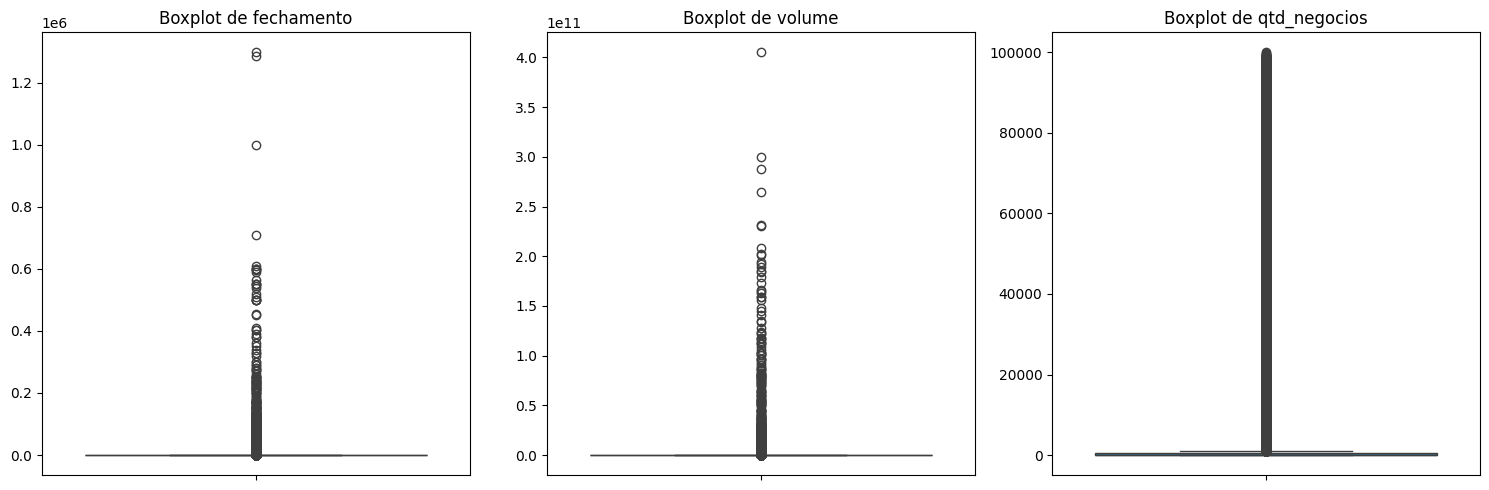

Os boxplots acima mostram a distribuição e a presença de outliers para o preço de fechamento, volume e quantidade de negócios. Valores fora dos 'bigodes' do boxplot são considerados potenciais outliers.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis selecionadas para boxplots
variaveis_para_boxplot = ['fechamento', 'volume', 'qtd_negocios']

plt.figure(figsize=(15, 5))
for i, col in enumerate(variaveis_para_boxplot):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_cotacao[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('') # Remove default y-label as it's redundant
plt.tight_layout()
plt.show()

print("Os boxplots acima mostram a distribuição e a presença de outliers para o preço de fechamento, volume e quantidade de negócios. Valores fora dos 'bigodes' do boxplot são considerados potenciais outliers.")

In [19]:
print("### Top 10 maiores valores para Fechamento, Volume e Quantidade de Negócios ###\n")

variables_to_analyze = ['fechamento', 'volume', 'qtd_negocios']

for var in variables_to_analyze:
    print(f"--- Top 10 Maiores Valores de {var.replace('_', ' ').title()} ---")

    # Seleciona as 10 maiores cotações para a variável atual
    top_10_values = df_cotacao.sort_values(by=var, ascending=False).head(10)

    # Mescla com df_papel e df_empresa para obter informações adicionais
    top_10_details = top_10_values.merge(df_papel, on='cd_papel', how='left') \
                                  .merge(df_empresa, on='cd_empresa', how='left')

    # Seleciona as colunas relevantes para exibição
    display_columns = ['data', 'codigo', 'empresa', var, 'abertura', 'maximo', 'minimo', 'volume', 'qtd_negocios']
    print(top_10_details[display_columns].to_markdown(index=False))
    print("\n")


### Top 10 maiores valores para Fechamento, Volume e Quantidade de Negócios ###

--- Top 10 Maiores Valores de Fechamento ---
| data                | codigo   | empresa      |       fechamento |         abertura |           maximo |           minimo |           volume |   qtd_negocios |
|:--------------------|:---------|:-------------|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|---------------:|
| 2012-07-16 00:00:00 | BFRE11   | BRAZILIAN FR |      1.29778e+06 |      1.29778e+06 |      1.29778e+06 |      1.29778e+06 |      5.42471e+08 |              1 |
| 2012-07-16 00:00:00 | BFRE12   | BRAZILIAN FR |      1.28595e+06 |      1.28595e+06 |      1.28595e+06 |      1.28595e+06 |      2.45617e+08 |              1 |
| 1994-06-24 00:00:00 | SLED3    | SARAIVA LIVR |      1e+06       |      1e+06       |      1e+06       |      1e+06       |      2e+06       |              1 |
| 1994-06-28 00:00:00 | ARN 3    | ARNO         | 710000        

## <a name='sec4'></a>📈 4. Ranking de Retorno, Volatilidade e Liquidez


Calcula o retorno diário (`pct_change`), o retorno acumulado (`(1+x).prod() - 1`), a volatilidade (desvio padrão dos retornos), o volume médio e o número médio de negócios para cada ativo (`cd_papel`). Em seguida, cria um DataFrame de ranking e mostra os 10 ativos com maior retorno acumulado.

Permite identificar rapidamente os ativos com melhor desempenho histórico, os mais arriscados (voláteis) e os mais negociados (líquidos).

In [20]:

df_cotacao["retorno"] = df_cotacao.groupby("cd_papel")["fechamento"].pct_change()

ret_acum = df_cotacao.groupby("cd_papel")["retorno"].apply(lambda x: (1+x).prod() - 1)
vol = df_cotacao.groupby("cd_papel")["retorno"].std()
liq_vol = df_cotacao.groupby("cd_papel")["volume"].mean()
liq_neg = df_cotacao.groupby("cd_papel")["qtd_negocios"].mean()

ranking = pd.DataFrame({
    "retorno_acumulado": ret_acum,
    "volatilidade": vol,
    "volume_medio": liq_vol,
    "negocios_medio": liq_neg
}).dropna()

ranking.sort_values("retorno_acumulado", ascending=False).head(10)


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:56: RuntimeWarning: invalid value encountered in reduce
  return umr_prod(a, axis, dtype, out, keepdims, initial, where)


,retorno_acumulado,volatilidade,volume_medio,negocios_medio
cd_papel,,,,
1418,3.041565e+06,2115.467397,110959.892670,19.260352
1091,1.521666e+06,942.237010,425058.808019,57.049730
1402,9.985704e+05,40.471169,16712.537906,2.823105
1401,9.719790e+05,20.738434,23393.760727,3.722157
854,8.177990e+05,16.788841,263317.489603,6.333333
1108,6.374128e+05,1019.812140,153675.997468,20.726582
758,5.131569e+05,47.141586,113414.578325,2.561576
1010,3.195990e+05,21643.664899,35499.801177,10.992467
860,2.823323e+05,31.705427,34438.505125,10.363141


## <a name='sec5'></a>📉 5. Volatilidade Histórica, ATR e Risco

Calcula o True Range (variação entre máxima e mínima do dia), o Average True Range (ATR) para medir a volatilidade média e o Coeficiente de Variação (CV), que é o desvio padrão dividido pela média. Essas métricas são agrupadas por ativo.

Fornece medidas robustas de risco e volatilidade dos ativos. O ATR é útil para definir stop-losses, enquanto o CV permite comparar a dispersão dos preços de ativos com médias diferentes, ajudando a entender o risco relativo de cada investimento.

In [21]:

df_cotacao["true_range"] = df_cotacao["maximo"] - df_cotacao["minimo"]

atr = df_cotacao.groupby("cd_papel")["true_range"].rolling(14).mean().reset_index()
atr = atr.groupby("cd_papel")["true_range"].mean()

cv = df_cotacao.groupby("cd_papel")["fechamento"].std() / df_cotacao.groupby("cd_papel")["fechamento"].mean()

risk_df = pd.DataFrame({
    "ATR": atr,
    "Coef_Variacao": cv
}).dropna()

risk_df.head()


,ATR,Coef_Variacao
cd_papel,,
1,0.957347,3.066068
2,0.247625,1.642285
3,0.741628,1.580036
4,0.142468,1.939166
5,567.092245,1.233071


## <a name='sec6'></a>⚠️ 6. Detecção de Anomalias

Para cada ativo, calcula a média e o desvio padrão do volume de negociação. Em seguida, identifica os dias em que o volume excedeu a média em mais de 3 desvios padrão, marcando-os como "Volume Spike".

Detecta eventos de negociação atípica que podem indicar notícias importantes, grandes movimentos de investidores institucionais ou mudanças significativas no sentimento do mercado. Esses "spikes" merecem análise mais detalhada para entender o que os causou.

In [24]:

anom_list = []

for papel, grupo in df_cotacao.groupby("cd_papel"):
    media = grupo["volume"].mean()
    desvio = grupo["volume"].std()

    spikes = grupo[grupo["volume"] > media + 3*desvio]
    spikes["anomalia"] = "Volume Spike"

    anom_list.append(spikes)

anomalias = pd.concat(anom_list)
anomalias.head()


A saída de streaming foi truncada nas últimas 5000 linhas.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spikes["anomalia"] = "Volume Spike"
/tmp/ipython-input-214653112.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spikes["anomalia"] = "Volume Spike"
/tmp/ipython-input-214653112.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spikes["anomalia"] = "Volume Spike"
/tmp/ipython-input-214653112.py:8: Setting

,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,qtd_tot_papeis,volume,f_ajuste,retorno,true_range,anomalia
7681,1,1994-02-09,150.01,170.0,150.01,161.72,162.40,162.50,39,180.00,2260000,365491800.0,1.141582,0.089933,19.99,Volume Spike
8341,1,1994-02-11,205.00,230.0,204.00,212.91,230.00,220.00,32,230.00,1110000,236340400.0,1.141582,0.179487,26.00,Volume Spike
8679,1,1994-02-17,240.00,270.0,240.00,255.92,270.00,260.01,36,270.00,1830000,468339700.0,1.141582,0.173913,30.00,Volume Spike
9301,1,1994-02-21,250.00,250.0,239.99,242.67,239.99,210.00,18,239.85,1420000,344592200.0,1.141582,-0.040040,10.01,Volume Spike
9598,1,1994-02-22,245.00,250.0,240.00,244.46,240.00,240.00,19,246.00,1540000,376479900.0,1.141582,0.000042,10.00,Volume Spike


## <a name='sec7'></a>📊 7. Indicadores Técnicos (RSI, MACD, Bandas, MMs)

Adiciona vários indicadores técnicos ao DataFrame de cotações para cada ativo: Índice de Força Relativa (RSI), Convergência/Divergência de Médias Móveis (MACD), Médias Móveis de 9 e 21 períodos (MM9, MM21) e Bandas de Bollinger (bb_upper, bb_mid, bb_low).

Estes indicadores são ferramentas essenciais na análise técnica, ajudando a identificar tendências de preço, condições de sobrecompra/sobrevenda, momentum e níveis de volatilidade.

In [27]:
import pandas_ta as ta
import numpy as np # Import numpy for NaN values

ind=[]
for papel, grp in df_cotacao.groupby("cd_papel"):
    g = grp.copy()
    g["rsi"] = ta.rsi(g["fechamento"], 14)

    # Calculate MACD and handle cases where it might return None
    macd_result = ta.macd(g["fechamento"])
    if macd_result is not None:
        g["macd"] = macd_result["MACD_12_26_9"]
    else:
        # Fill 'macd' column with NaN if calculation is not possible
        g["macd"] = pd.Series(np.nan, index=g.index)

    g["mm9"] = g["fechamento"].rolling(9).mean()
    g["mm21"] = g["fechamento"].rolling(21).mean()

    # Calculate Bollinger Bands and handle cases where it might return None
    bb_result = ta.bbands(g["fechamento"])
    if bb_result is not None:
        g["bb_upper"], g["bb_mid"], g["bb_low"] = bb_result.iloc[:,0], bb_result.iloc[:,1], bb_result.iloc[:,2]
    else:
        # Fill Bollinger Band columns with NaN if calculation is not possible
        g["bb_upper"] = pd.Series(np.nan, index=g.index)
        g["bb_mid"] = pd.Series(np.nan, index=g.index)
        g["bb_low"] = pd.Series(np.nan, index=g.index)

    ind.append(g)

df_ind = pd.concat(ind).sort_values(["cd_papel","data"])
df_ind.head()

/tmp/ipython-input-1246278712.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ind = pd.concat(ind).sort_values(["cd_papel","data"])


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,...,f_ajuste,retorno,true_range,rsi,macd,mm9,mm21,bb_upper,bb_mid,bb_low
0,1,1994-01-03,50.0,53.00,50.00,51.53,53.00,51.02,10,53.00,...,1.141582,NaN,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,1,1994-01-04,54.0,56.00,54.00,55.36,56.00,55.55,16,56.00,...,1.141582,0.056604,2.00,100.0,NaN,NaN,NaN,NaN,NaN,NaN
445,1,1994-01-05,58.0,58.00,57.15,57.51,58.00,57.50,15,59.00,...,1.141582,0.035714,0.85,100.0,NaN,NaN,NaN,NaN,NaN,NaN
718,1,1994-01-06,60.0,60.01,59.01,59.92,59.88,59.00,26,59.87,...,1.141582,0.032414,1.00,100.0,NaN,NaN,NaN,NaN,NaN,NaN
1004,1,1994-01-07,59.8,67.00,59.80,61.83,67.00,67.00,26,0.00,...,1.141582,0.118904,7.20,100.0,NaN,NaN,NaN,48.262983,58.776,69.289017


## <a name='sec8'></a>🧩 8. Correlação Entre Ativos

Cria uma tabela dinâmica dos retornos diários de todos os ativos e, em seguida, calcula a matriz de correlação entre eles. Esta matriz é visualizada através de um mapa de calor (heatmap).

Entender a correlação entre ativos é vital para a diversificação de portfólio. Ativos com baixa ou correlação negativa são desejáveis para reduzir o risco geral do portfólio, enquanto alta correlação pode indicar que os ativos se movem em sincronia.

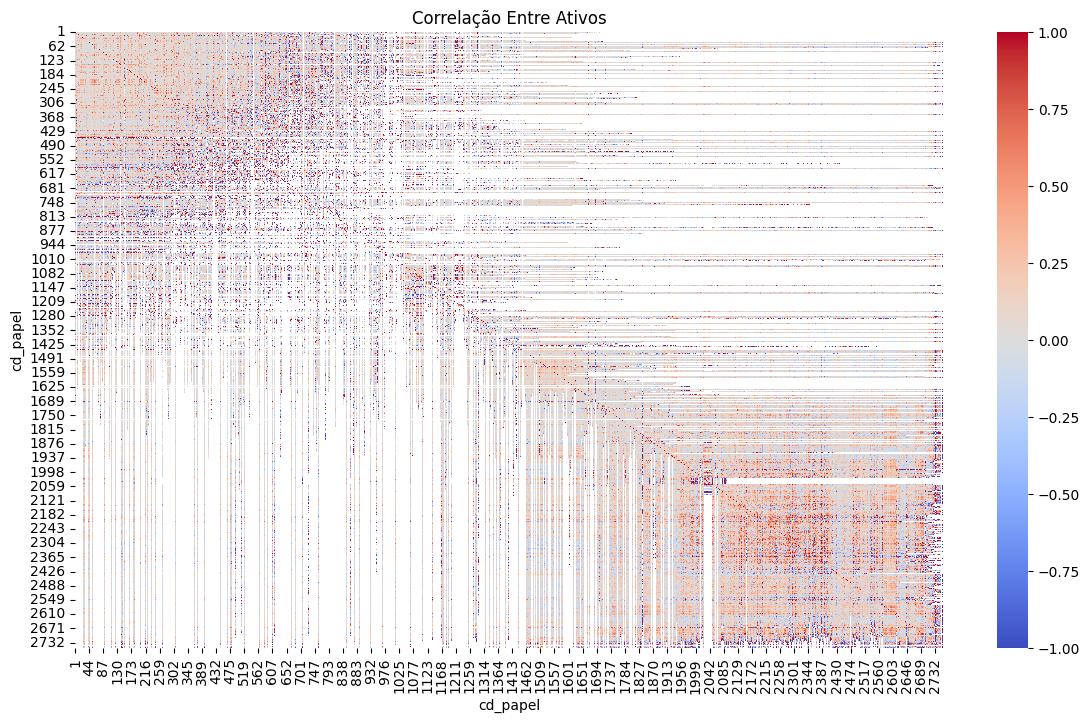

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

ret_pivot = df_cotacao.pivot_table(index="data", columns="cd_papel", values="retorno")
cor = ret_pivot.corr()

plt.figure(figsize=(14,8))
sns.heatmap(cor, cmap="coolwarm")
plt.title("Correlação Entre Ativos")
plt.show()


## <a name='sec9'></a>🧬 9. Clusterização de Ações

Utiliza os retornos acumulados e a volatilidade de cada ativo, padroniza esses dados e aplica o algoritmo K-Means para agrupar os ativos em 5 clusters. O número do cluster é adicionado ao DataFrame `cluster_base`.

Ajuda a identificar grupos de ativos com perfis de risco e retorno semelhantes. Isso pode ser usado para entender a estrutura do mercado, otimizar a diversificação de portfólio ou desenvolver estratégias de investimento focadas em características específicas de clusters.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_base = ranking[["retorno_acumulado","volatilidade"]].dropna()

sc = StandardScaler()
scaled = sc.fit_transform(cluster_base)

km = KMeans(n_clusters=5, random_state=42)
cluster_base["cluster"] = km.fit_predict(scaled)

cluster_base.head()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b61e1f967a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

,retorno_acumulado,volatilidade,cluster
cd_papel,,,
1,-0.999340,0.075948,0
2,14.000000,209.166963,0
3,0.118077,1.290814,0
4,4.914286,1.544152,0
5,-0.994227,0.329102,0


## <a name='sec10'></a>🔎 10. Volume Spike – Detector

Exibe o cabeçalho do DataFrame `anomalias`, que já foi gerado na Seção 6 e contém os registros de dias com picos de volume.

Reafirma a identificação de momentos incomuns de alta atividade de negociação para cada papel, o que pode sinalizar eventos importantes que influenciam o preço e que valem a pena investigar mais a fundo.

In [30]:

spike_df = anomalias[["cd_papel","data","volume","anomalia"]]
spike_df.head()


,cd_papel,data,volume,anomalia
7681,1,1994-02-09,365491800.0,Volume Spike
8341,1,1994-02-11,236340400.0,Volume Spike
8679,1,1994-02-17,468339700.0,Volume Spike
9301,1,1994-02-21,344592200.0,Volume Spike
9598,1,1994-02-22,376479900.0,Volume Spike


## <a name='sec11'></a>📈 11. Retorno Acumulado Comparativo

Calcula o retorno acumulado diário para cada ativo, aplicando a função `cumprod()` (produto cumulativo) aos retornos diários. Isso mostra a evolução do valor de um investimento hipotético ao longo do tempo.

Permite visualizar e comparar o desempenho histórico de diferentes ativos como se um investimento inicial tivesse sido feito, mostrando o crescimento (ou perda) do capital ao longo do tempo. É fundamental para avaliar a performance de um ativo ou portfólio.

In [31]:

ret_acum_daily = df_cotacao.groupby("cd_papel")["retorno"].apply(lambda x: (1+x).cumprod())
ret_acum_daily = ret_acum_daily.reset_index(name="retorno_acum")
ret_acum_daily.head()


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


,cd_papel,level_1,retorno_acum
0,1,0,NaN
1,1,190,1.056604
2,1,445,1.094340
3,1,718,1.129811
4,1,1004,1.264151


## <a name='sec12'></a>⚙️ 12. Estratégia MM9 x MM21

Implementa uma estratégia de negociação baseada no cruzamento de médias móveis de 9 e 21 períodos. Um sinal de compra é gerado quando a MM9 cruza acima da MM21. A coluna `posicao` simula a manutenção da posição, e `ret_estrategia` calcula o retorno diário da estratégia.
Simula uma estratégia de negociação comum para avaliar seu potencial de lucro. Permite entender como os sinais de indicadores técnicos podem ser traduzidos em decisões de compra/venda e quais retornos poderiam ser esperados.

In [32]:

estr = df_ind.copy()
estr["sinal"] = (estr["mm9"] > estr["mm21"]).astype(int)
estr["posicao"] = estr.groupby("cd_papel")["sinal"].shift(1)
estr["ret_estrategia"] = estr["posicao"] * estr["retorno"]
estr.head()


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,...,rsi,macd,mm9,mm21,bb_upper,bb_mid,bb_low,sinal,posicao,ret_estrategia
0,1,1994-01-03,50.0,53.00,50.00,51.53,53.00,51.02,10,53.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
190,1,1994-01-04,54.0,56.00,54.00,55.36,56.00,55.55,16,56.00,...,100.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0
445,1,1994-01-05,58.0,58.00,57.15,57.51,58.00,57.50,15,59.00,...,100.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0
718,1,1994-01-06,60.0,60.01,59.01,59.92,59.88,59.00,26,59.87,...,100.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0
1004,1,1994-01-07,59.8,67.00,59.80,61.83,67.00,67.00,26,0.00,...,100.0,NaN,NaN,NaN,48.262983,58.776,69.289017,0,0.0,0.0


## <a name='sec13'></a>📊 13. Dashboard Financeiro – Plotly

Seleciona um ativo (o primeiro `cd_papel` único) e cria um gráfico de candlestick interativo usando a biblioteca Plotly. O gráfico exibe os preços de abertura, máxima, mínima e fechamento ao longo do tempo.

**Insight:** Fornece uma visualização detalhada do movimento dos preços de um ativo, essencial para a análise técnica. Gráficos de candlestick ajudam a identificar padrões de preço, tendências e pontos de virada no mercado.

In [33]:

import plotly.graph_objects as go

papel = df_cotacao["cd_papel"].unique()[0]
subset = df_cotacao[df_cotacao["cd_papel"] == papel]

fig = go.Figure(data=[go.Candlestick(
    x=subset["data"],
    open=subset["abertura"],
    high=subset["maximo"],
    low=subset["minimo"],
    close=subset["fechamento"]
)])

fig.update_layout(
    title=f"Gráfico de Candles — {papel}",
    xaxis_title="Data",
    yaxis_title="Preço"
)

fig.show()


## <a name='sec14'></a>📅 14. Event Study

### 📅 14. Event Study

**O que o código faz:** Combina os DataFrames `df_eventocotacao` e `df_evento` para juntar informações detalhadas sobre eventos corporativos (como dividendos, bonificações) com os dados de cotação dos respectivos papéis.

**Insight:** Prepara os dados para analisar o impacto de eventos específicos (ex: anúncio de dividendos, desdobramentos de ações) no preço dos ativos. Isso ajuda a entender como o mercado reage a informações corporativas importantes.

In [34]:

df_events = df_eventocotacao.merge(df_evento, on="cd_evento", how="left")
df_events.head()


,cd_papel,data,cd_evento,valor_perc,aplicado,descricao,ds_bolsa
0,26,1994-01-05,1,1.958763,1,ex-dividendos,ED
1,26,1994-01-05,2,1.958763,1,ex-bonificacao,EB
2,26,1994-01-05,3,1.958763,1,ex-subscrição,ES
3,27,1994-01-05,1,1.924528,1,ex-dividendos,ED
4,27,1994-01-05,2,1.924528,1,ex-bonificacao,EB


## <a name='sec15'></a>📉 15. Microestrutura – Spread e Pressão

### 📉 15. Microestrutura – Spread e Pressão

**O que o código faz:** Calcula o "spread" (diferença entre preço de oferta de venda e compra), a "pressão de compra" (fechamento menos oferta de compra) e a "pressão de venda" (oferta de venda menos fechamento) para cada cotação.

**Insight:** Essas métricas fornecem informações sobre a liquidez do mercado e a dinâmica de oferta e demanda no nível micro. Um spread menor indica maior liquidez, enquanto as pressões indicam o lado do mercado que está dominando a formação do preço.

In [35]:

micro = df_cotacao.copy()
micro["spread"] = micro["oferta_venda"] - micro["oferta_compra"]
micro["pressao_compra"] = micro["fechamento"] - micro["oferta_compra"]
micro["pressao_venda"] = micro["oferta_venda"] - micro["fechamento"]
micro.head()


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,qtd_tot_papeis,volume,f_ajuste,retorno,true_range,spread,pressao_compra,pressao_venda
0,1,1994-01-03,50.0,53.00,50.00,51.53,53.00,51.02,10,53.00,240000,12369300.0,1.141582,NaN,3.00,1.98,1.98,0.00
190,1,1994-01-04,54.0,56.00,54.00,55.36,56.00,55.55,16,56.00,690000,38203600.0,1.141582,0.056604,2.00,0.45,0.45,0.00
445,1,1994-01-05,58.0,58.00,57.15,57.51,58.00,57.50,15,59.00,460000,26457000.0,1.141582,0.035714,0.85,1.50,0.50,1.00
718,1,1994-01-06,60.0,60.01,59.01,59.92,59.88,59.00,26,59.87,1190000,71313200.0,1.141582,0.032414,1.00,0.87,0.88,-0.01
1004,1,1994-01-07,59.8,67.00,59.80,61.83,67.00,67.00,26,0.00,900000,55652100.0,1.141582,0.118904,7.20,-67.00,0.00,-67.00


## <a name='sec16'></a>🕳️ 16. Detecção de Gaps

### 🕳️ 16. Detecção de Gaps

**O que o código faz:** Calcula a diferença entre o preço de abertura de um dia e o preço de fechamento do dia anterior para cada ativo, identificando "gaps" no preço.

**Insight:** Gaps de preço são descontinuidades que podem ser causadas por notícias ou eventos que ocorrem fora do horário de negociação. A análise de gaps é usada por traders para identificar padrões de continuação ou reversão de tendência.

In [36]:

gaps = df_cotacao.copy()
gaps["fech_ant"] = gaps.groupby("cd_papel")["fechamento"].shift(1)
gaps["gap"] = gaps["abertura"] - gaps["fech_ant"]
gaps.dropna().head()


,cd_papel,data,abertura,maximo,minimo,medio,fechamento,oferta_compra,qtd_negocios,oferta_venda,qtd_tot_papeis,volume,f_ajuste,retorno,true_range,fech_ant,gap
190,1,1994-01-04,54.0,56.00,54.00,55.36,56.00,55.55,16,56.00,690000,38203600.0,1.141582,0.056604,2.00,53.00,1.00
445,1,1994-01-05,58.0,58.00,57.15,57.51,58.00,57.50,15,59.00,460000,26457000.0,1.141582,0.035714,0.85,56.00,2.00
718,1,1994-01-06,60.0,60.01,59.01,59.92,59.88,59.00,26,59.87,1190000,71313200.0,1.141582,0.032414,1.00,58.00,2.00
1004,1,1994-01-07,59.8,67.00,59.80,61.83,67.00,67.00,26,0.00,900000,55652100.0,1.141582,0.118904,7.20,59.88,-0.08
1309,1,1994-01-10,70.0,72.00,67.00,71.14,72.00,70.00,17,72.00,350000,24899800.0,1.141582,0.074627,5.00,67.00,3.00


In [ ]:
# Criando uma pasta para organizar (opcional, se rodar local)
import os
os.makedirs('relatorios_csv', exist_ok=True)

# Exportando os principais DataFrames
ranking.to_csv('relatorios_csv/1_ranking_performance.csv')
risk_df.to_csv('relatorios_csv/2_risco_atr.csv')
anomalias.to_csv('relatorios_csv/3_anomalias_volume.csv', index=False)
df_ind.to_csv('relatorios_csv/4_indicadores_tecnicos.csv', index=False)
cluster_base.to_csv('relatorios_csv/5_clusters_acoes.csv')
cor.to_csv('relatorios_csv/6_matriz_correlacao.csv')
estr.to_csv('relatorios_csv/7_backtest_estrategia.csv', index=False)
micro.to_csv('relatorios_csv/8_microestrutura.csv', index=False)

print("Arquivos CSV gerados com sucesso!")